# Salary dataset

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import root_mean_squared_error

In [2]:
df = pd.read_csv('../data/Salary.csv')

In [3]:
df.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  35 non-null     float64
 1   Salary           35 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 692.0 bytes


Text(0, 0.5, 'Salary')

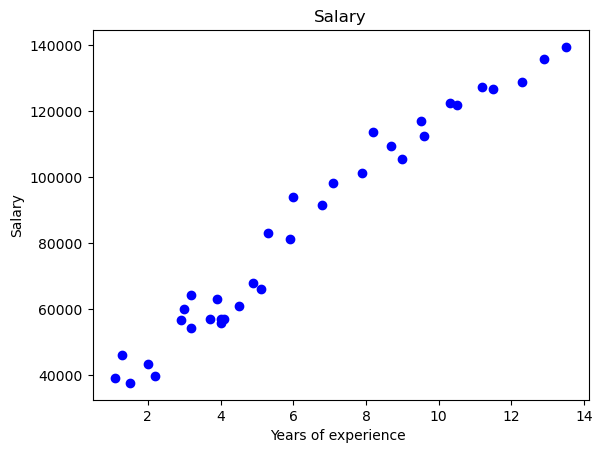

In [5]:
plt.plot(df.YearsExperience, df.Salary, 'o', color='blue')
plt.title('Salary')
plt.xlabel("Years of experience ")
plt.ylabel("Salary")

## Baseline model

In [6]:
X = np.array(df['YearsExperience']).reshape(-1, 1)
y = df.Salary

In [7]:
X_train, X_val, y_train, y_val = train_test_split(X.reshape(-1, 1), y, test_size=0.2, random_state=1)

In [8]:
lr = LinearRegression()

In [9]:
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
y_pred = lr.predict(X_val)

In [12]:
print(f"Root Mean Squared Error is: {root_mean_squared_error(y_val, y_pred)}")

Root Mean Squared Error is: 6348.866720688848


## Random Forest

In [14]:
rf_model = RandomForestRegressor(
    n_estimators=100,        # Number of trees
    max_depth=10,            # Maximum depth of trees
    min_samples_split=5,     # Minimum samples to split a node
    min_samples_leaf=2,      # Minimum samples in leaf node
    random_state=42
)

In [16]:
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_val)

In [17]:
print(f"Root Mean Squared Error is: {root_mean_squared_error(y_val, y_pred)}")

Root Mean Squared Error is: 6726.372947722307


## Support vector machine

In [20]:
svr_model = SVR(C=1.0, epsilon=0.2)

In [21]:
svr_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_val)

In [22]:
print(f"Root Mean Squared Error is: {root_mean_squared_error(y_val, y_pred)}")

Root Mean Squared Error is: 6726.372947722307
